# High-dimensional Classification

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Load and explore a real chemical dataset and identify class imbalance
- Apply an RBF kernel transformation to a high-dimensional feature matrix and explain its effect
- Implement a kernel-augmented SVM by hand and compare it to sklearn's `SVC`
- Use `GridSearchCV` to tune SVC hyperparameters on a held-out training set
- Evaluate classifier performance using accuracy, precision, recall, and confusion matrices
- Distinguish categorical from ordinal variables and apply one-hot encoding with `pd.get_dummies` and a leakage-safe `OneHotEncoder` + `ColumnTransformer` pipeline
- Apply and interpret a depth-limited decision tree and read feature importances from the result
- Derive the five steps of Linear Discriminant Analysis (LDA) and explain why it finds more class-discriminative projections than PCA
:::

The previous chapters introduced classification algorithms on simple two-dimensional
toy datasets. Here we apply these methods to a **real chemical engineering problem**:
predicting whether a given elemental combination will form a stable perovskite crystal
structure. This introduces challenges that toy data conceals — correlated features,
class imbalance, and the need to carefully separate training from test data before any
hyperparameter tuning.

Working with real data also requires thinking carefully about the **full modeling
pipeline**. In research and industrial settings, a common mistake is to use the test
set — even informally, by looking at results and adjusting the model — before final
evaluation. This form of **data leakage** produces optimistic accuracy estimates that
do not generalize. The correct procedure is:

1. Split data into training and test sets immediately.
2. Perform all preprocessing, feature selection, and hyperparameter tuning *on the
   training set only* (typically using cross-validation).
3. Evaluate the final model on the test set **once**.

We follow this protocol throughout this chapter.

## Perovskite Dataset

Perovskites (ABX$_3$ compounds) are a structurally versatile class of oxide and halide
materials with applications ranging from catalysis to photovoltaics. Whether a given
combination of A, B, and X elements adopts the perovskite structure depends on subtle
geometric and electronic factors. The dataset used here comes from Bartel et al. (2019),
who compiled 576 compounds with experimentally confirmed labels ($+1$ = perovskite,
$-1$ = non-perovskite) alongside eight numerical features:

| Feature | Description |
|---|---|
| `nA`, `nB`, `nX` | Formal oxidation states of A, B, X ions |
| `rA`, `rB`, `rX` | Ionic radii (Angstrom) |
| `t` | Goldschmidt tolerance factor |
| `tau` | New tolerance factor proposed in the paper |

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('../settings/plot_style.mplstyle')

clrs = np.array(['#003057', '#EAAA00', '#4B8B9B', '#B3A369', '#377117',
                 '#1879DB', '#8E8B76', '#F5D580', '#002233'])

In [2]:
df = pd.read_csv('data/perovskite_data.csv')
df.head(10)

,ABX3,A,B,X,nA,nB,nX,rA (Ang),rB (Ang),rX (Ang),t,tau,exp_label
0,AgBiO3,Ag,Bi,O,1,5,-2,1.28,0.76,1.40,0.88,4.07,-1
1,AgBrO3,Ag,Br,O,1,5,-2,1.28,0.31,1.40,1.11,6.43,-1
2,AgCaCl3,Ag,Ca,Cl,1,2,-1,1.28,1.00,1.81,0.78,6.00,-1
3,AgCdBr3,Ag,Cd,Br,1,2,-1,1.28,0.95,1.96,0.79,5.58,-1
4,AgClO3,Ag,Cl,O,1,5,-2,1.28,0.12,1.40,1.25,15.17,-1
5,AgCoF3,Ag,Co,F,1,2,-1,1.28,0.74,1.33,0.89,3.96,1
6,AgCuF3,Ag,Cu,F,1,2,-1,1.28,0.73,1.33,0.90,3.94,1
7,AgMgCl3,Ag,Mg,Cl,1,2,-1,1.28,0.72,1.81,0.86,4.60,-1
8,AgMgF3,Ag,Mg,F,1,2,-1,1.28,0.72,1.33,0.90,3.94,1
9,AgMnF3,Ag,Mn,F,1,2,-1,1.28,0.83,1.33,0.85,4.16,1


In [3]:
feature_columns = ['nA', 'nB', 'nX', 'rA (Ang)', 'rB (Ang)', 'rX (Ang)', 't', 'tau']

X_perov = df[feature_columns].values
y_perov = df['exp_label'].values

print(f'Feature matrix shape: {X_perov.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y_perov, return_counts=True)))}')

Feature matrix shape: (576, 8)
Class distribution: {np.int64(-1): np.int64(263), np.int64(1): np.int64(313)}


Note that the labels are $\pm 1$ rather than $0/1$. The classes are not perfectly
balanced — this matters when interpreting accuracy alone. A naive classifier that
predicts "non-perovskite" for every sample would still achieve moderate accuracy
simply by exploiting the class imbalance, without learning anything useful.
This is why precision, recall, and the confusion matrix are essential supplements
to accuracy for imbalanced binary classification tasks.

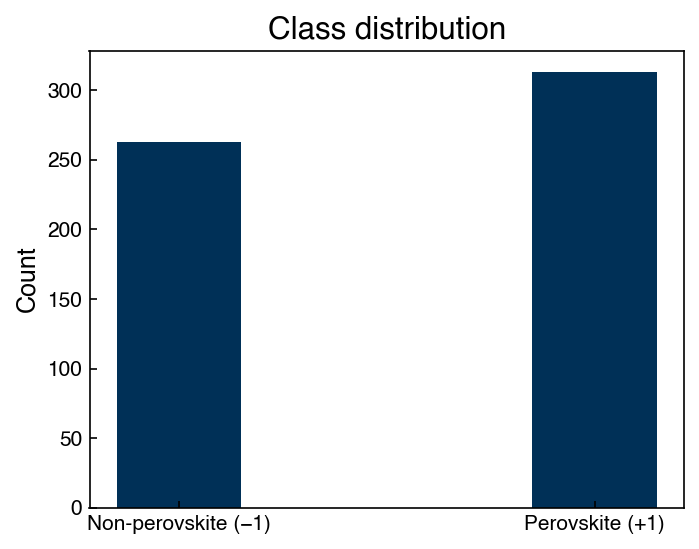

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(y_perov, bins=[-1.5, -0.5, 0.5, 1.5], rwidth=0.6)
ax.set_xticks([-1, 1])
ax.set_xticklabels(['Non-perovskite (−1)', 'Perovskite (+1)'])
ax.set_ylabel('Count')
ax.set_title('Class distribution')
plt.tight_layout()
plt.show()

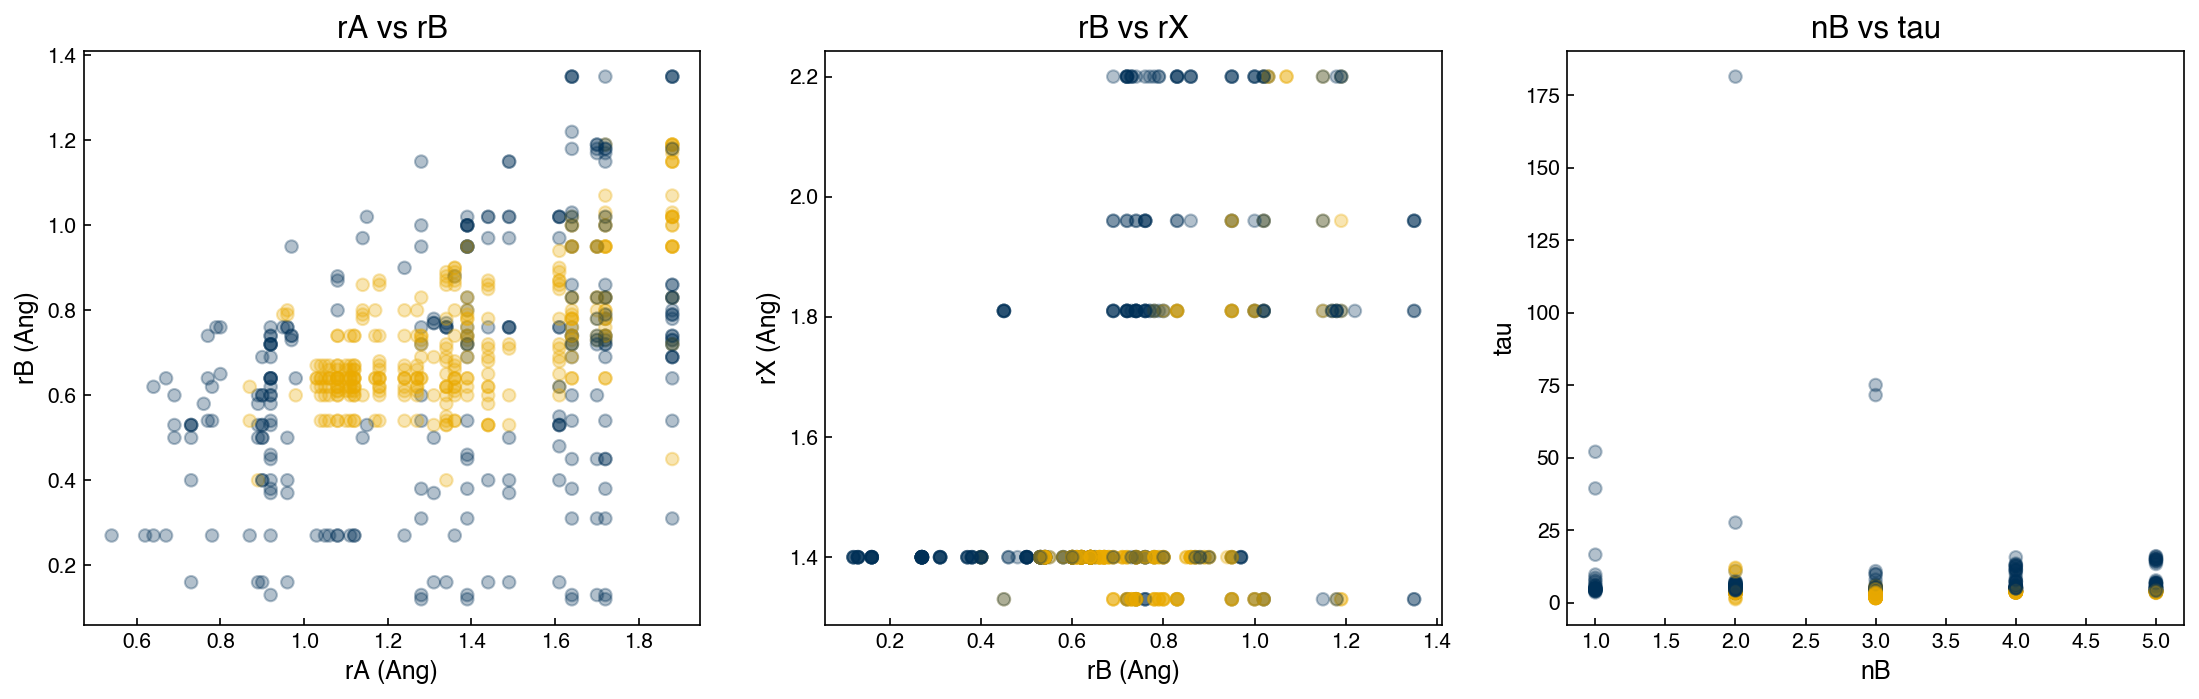

In [5]:
# map y in {-1, 1} to color indices {0, 1}
cidx = ((y_perov + 1) // 2).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X_perov[:, 3], X_perov[:, 4], c=clrs[cidx], alpha=0.3)
axes[0].set_xlabel(feature_columns[3])
axes[0].set_ylabel(feature_columns[4])
axes[0].set_title('rA vs rB')

axes[1].scatter(X_perov[:, 4], X_perov[:, 5], c=clrs[cidx], alpha=0.3)
axes[1].set_xlabel(feature_columns[4])
axes[1].set_ylabel(feature_columns[5])
axes[1].set_title('rB vs rX')

axes[2].scatter(X_perov[:, 1], X_perov[:, 7], c=clrs[cidx], alpha=0.3)
axes[2].set_xlabel(feature_columns[1])
axes[2].set_ylabel(feature_columns[7])
axes[2].set_title('nB vs tau')

plt.tight_layout()
plt.show()

The scatter plots reveal that no single pair of features cleanly separates the two
classes. Points of both labels are heavily intermixed in all projections, although
`nB` vs `tau` (right panel) shows some tendency for perovskites to cluster at
higher $\tau$ values. This motivates the use of all features together and non-linear
decision boundaries — no simple cut in any two-dimensional projection will suffice.

This is also a reminder that high-dimensional intuition is hard: the eight features
together may define boundaries that are invisible in any pairwise projection but are
readily learned by a kernel SVM or decision tree operating on the full feature matrix.

:::{exercise}
:label: ex-cls-perov-scatter

Using the perovskite feature matrix `X_perov` and labels `y_perov`, produce scatter
plots for all pairs among the four features `rA (Ang)`, `rB (Ang)`, `t`, and `tau`.
Arrange them in a 4×4 grid (diagonal can show histograms). Identify which feature
pair appears to give the clearest visual separation between classes.
:::

---

## Kernel-based Classification

### The RBF Kernel Transformation

In Topic 3.2 we saw that kernels implicitly map data into a higher-dimensional feature
space where linear classifiers can find non-linear boundaries. Here we apply this idea
explicitly: compute the **radial basis function (RBF) kernel matrix** $K$ where

$$K_{ij} = \exp\!\left(-\gamma \|\vec{x}_i - \vec{x}_j\|^2\right)$$

Each row of $K$ is a new feature vector for sample $i$, encoding its similarity to
every other sample. The result is a $576 \times 576$ matrix, regardless of the original
number of features.

In [6]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import accuracy_score, confusion_matrix

X_kernel = rbf_kernel(X_perov, X_perov, gamma=0.02)
print(f'Kernel matrix shape: {X_kernel.shape}')

Kernel matrix shape: (576, 576)


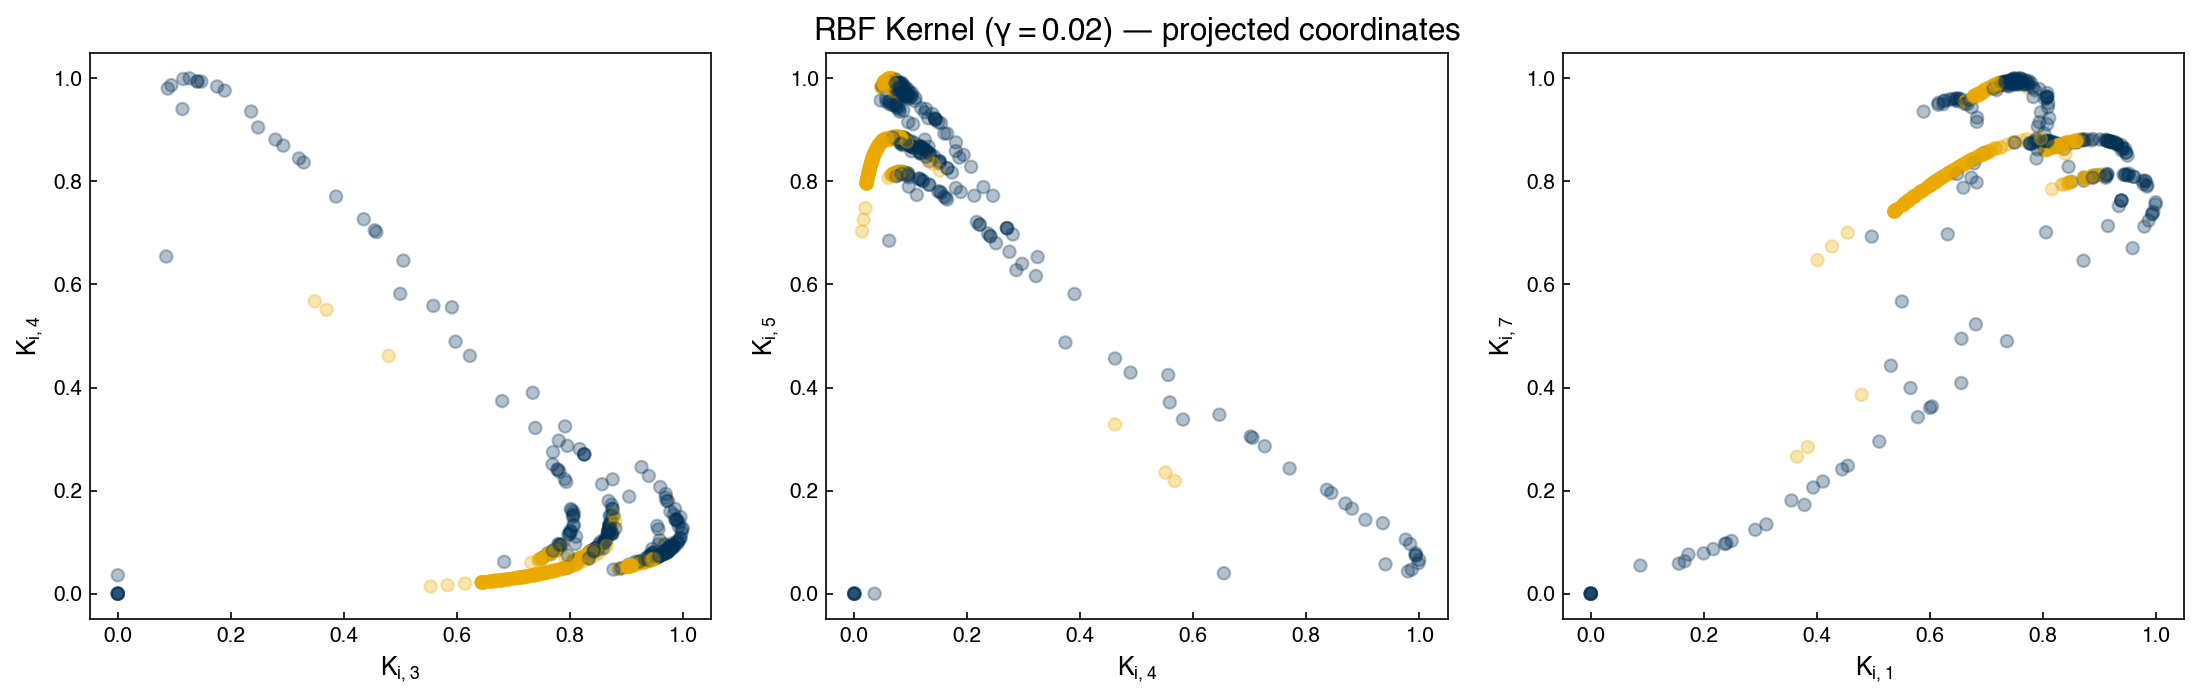

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X_kernel[:, 3], X_kernel[:, 4], c=clrs[cidx], alpha=0.3)
axes[0].set_xlabel('$K_{i,3}$')
axes[0].set_ylabel('$K_{i,4}$')

axes[1].scatter(X_kernel[:, 4], X_kernel[:, 5], c=clrs[cidx], alpha=0.3)
axes[1].set_xlabel('$K_{i,4}$')
axes[1].set_ylabel('$K_{i,5}$')

axes[2].scatter(X_kernel[:, 1], X_kernel[:, 7], c=clrs[cidx], alpha=0.3)
axes[2].set_xlabel('$K_{i,1}$')
axes[2].set_ylabel('$K_{i,7}$')

axes[1].set_title('RBF Kernel ($\gamma = 0.02$) — projected coordinates')
plt.tight_layout()
plt.show()

### Manual SVM on Raw and Kernel-transformed Data

To build intuition, we first train our custom margin-loss SVM (from Topic 3.2) on
just two features, both before and after the kernel transform, and compare accuracy.

In [8]:
from scipy.optimize import minimize

def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def linear_classifier(X, w):
    p = add_intercept(X) @ w
    return np.where(p > 0, 1, -1)

def regularized_cost(w, X, y, alpha=1):
    Xb = add_intercept(X) @ w
    cost = np.sum(np.maximum(0, 1 - y * Xb))
    cost += alpha * np.linalg.norm(w[1:], 2)
    return cost

In [9]:
# SVM on original 2-feature data (rA, rB)
w_guess = np.array([-10., -4., -10.])
result = minimize(regularized_cost, w_guess, args=(X_perov[:, 3:5], y_perov, 1))
w_raw = result.x

pred_raw = linear_classifier(X_perov[:, 3:5], w_raw)
print(f'Accuracy (raw 2 features):    {accuracy_score(y_perov, pred_raw):.3f}')

Accuracy (raw 2 features):    0.630


In [10]:
# SVM on kernel-transformed 2 features
result_k = minimize(regularized_cost, w_guess, args=(X_kernel[:, 3:5], y_perov, 1))
w_kernel = result_k.x

pred_kernel = linear_classifier(X_kernel[:, 3:5], w_kernel)
print(f'Accuracy (kernel 2 features): {accuracy_score(y_perov, pred_kernel):.3f}')

Accuracy (kernel 2 features): 0.847


The kernel-transformed version substantially outperforms the raw linear classifier
on the same two features, demonstrating that the implicit higher-dimensional mapping
allows a linear boundary in kernel space to act as a non-linear boundary in the
original feature space.

Note that both models are still trained and evaluated on the *same* data here —
we are illustrating the effect of the kernel, not measuring generalization.
True generalization requires a held-out test set, which we use in the next section.

### scikit-learn SVC

The `sklearn.svm.SVC` handles the kernel transformation internally and is far more
efficient than our manual approach. Let's compare results using 2 features vs. all 8:

In [11]:
from sklearn.svm import SVC

svc_2feat = SVC(kernel='rbf', gamma=100, C=1000)
svc_2feat.fit(X_perov[:, 3:5], y_perov)
print(f'SVC (2 features, train): {svc_2feat.score(X_perov[:, 3:5], y_perov):.3f}')

svc_all = SVC(kernel='rbf', gamma=100, C=1000)
svc_all.fit(X_perov, y_perov)
print(f'SVC (all features, train): {svc_all.score(X_perov, y_perov):.3f}')

SVC (2 features, train): 0.925
SVC (all features, train): 0.997


Both achieve near-perfect *training* accuracy — a warning sign of overfitting.
With $\gamma = 100$ and $C = 1000$, the RBF kernel is extremely tight, creating
tiny decision regions around individual training points. This is classic overfitting:
the model has memorized the training data rather than learned generalizable structure.
We must evaluate on held-out data and tune hyperparameters properly.

### Hyperparameter Optimization with GridSearchCV

We perform a proper train/test split first, then search only within the training set.
`GridSearchCV` trains a model for every combination of hyperparameters in the grid,
using $k$-fold cross-validation to estimate generalization error. Because this entire
search happens inside the training set, the test set remains completely unseen until
we call `.score()` on the best estimator:

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils import shuffle

X_train, X_test, y_train, y_test = train_test_split(
    X_perov, y_perov, test_size=0.33, random_state=42)

X_train, y_train = shuffle(X_train, y_train, random_state=42)

sigmas = np.array([1e-3, 1e-2, 1e-1, 1, 10, 100])
gammas = 1. / (2 * sigmas**2)
alphas = np.array([1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])
Cs = 1 / alphas

svc = SVC(kernel='rbf')
svc_search = GridSearchCV(svc, {'C': Cs, 'gamma': gammas}, cv=3)
svc_search.fit(X_train, y_train)

print(f'Best params:   {svc_search.best_params_}')
print(f'CV accuracy:   {svc_search.best_score_:.3f}')

Best params:   {'C': np.float64(1000.0), 'gamma': np.float64(0.5)}
CV accuracy:   0.925


In [13]:
best_svc = svc_search.best_estimator_
print(f'Test accuracy: {best_svc.score(X_test, y_test):.3f}')

Test accuracy: 0.927


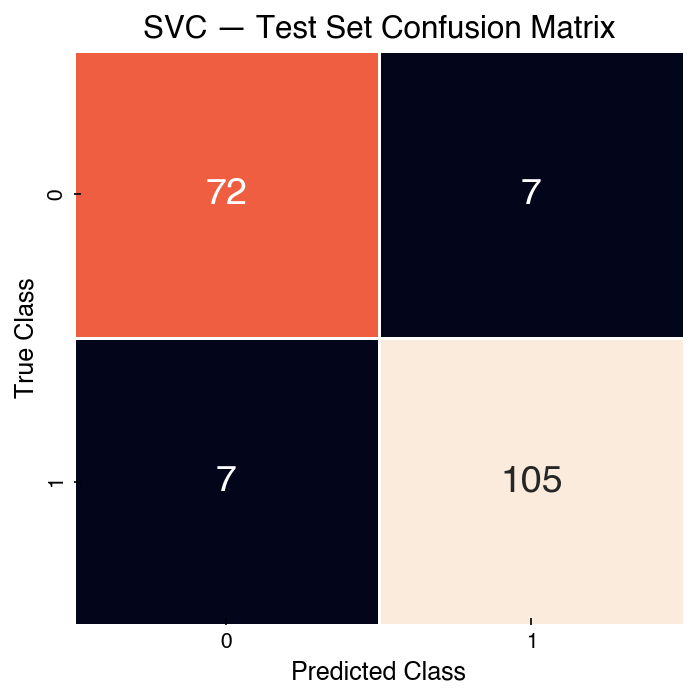

In [14]:
y_pred_svc = best_svc.predict(X_test)
cm = confusion_matrix(y_test, y_pred_svc)

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, cbar=False, fmt='d', ax=ax)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title('SVC — Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

### Demonstration: Precision and Recall

Accuracy alone is misleading when classes are imbalanced. Precision and recall give
a more complete picture. Recall the confusion matrix entries:

|  | Predicted Positive | Predicted Negative |
|---|---|---|
| **True Positive** | TP | FN |
| **True Negative** | FP | TN |

From these counts we define:

- **Accuracy** = $\frac{TP + TN}{TP + TN + FP + FN}$ — fraction of all predictions correct
- **Precision** = $\frac{TP}{TP + FP}$ — of all predicted positives, how many are correct?
- **Recall** = $\frac{TP}{TP + FN}$ — of all true positives, how many did we catch?
- **F1 score** = $\frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ — harmonic mean of precision and recall

In materials screening, **recall** is often the priority: missing a promising
perovskite candidate (false negative) may be more costly than following up on a
false positive in the lab. Choosing which metric to optimize is a domain decision,
not a modeling one.

In [15]:
tn, fp, fn, tp = cm.ravel()

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)

print(f'Accuracy:  {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall:    {recall:.3f}')
print(f'F1 score:  {f1:.3f}')

Accuracy:  0.927
Precision: 0.938
Recall:    0.938
F1 score:  0.938


:::{exercise}
:label: ex-cls-perov-knn

Apply `KNeighborsClassifier` (from sklearn) to the full perovskite feature matrix
using the same train/test split (`X_train`, `X_test`, `y_train`, `y_test`).
Use `GridSearchCV` with 3-fold cross-validation to search over
$k \in \{3, 5, 10, 20, 50\}$. Print the best $k$, the CV accuracy, and the test
accuracy. Compare to the best SVC result above.
:::

---

## Categorical Variables and One-Hot Encoding

So far every model in this chapter has used only the numeric features — oxidation
states, ionic radii, and tolerance factors. But the dataset also records *which
elements* occupy the A, B, and X sites, and element identity is chemical information
a model might exploit. These are **categorical variables**, and they require special
treatment before any distance-based classifier can use them.

### Categorical vs. Ordinal Variables

Numerical features can be measured on a continuous scale, but many real datasets contain **discrete variables** that represent categories rather than magnitudes. There are two important types:

- **Ordinal variables**: the order of values carries meaning (e.g., satisfaction rating 1–5, polymer chain length). Converting to a continuous float is often reasonable.
- **Categorical variables**: the values are labels with no inherent ordering (e.g., element symbol, solvent name, process type). Representing "Ba" as 1 and "Sr" as 2 would mislead any model into thinking Ba is "twice" some quantity relative to Sr.

The standard solution for categorical variables is **one-hot encoding**: replace a column with $k$ unique values by $k$ binary columns (indicators), one per category. For example, a three-level color variable becomes:

| color | color_red | color_blue | color_green |
|---|---|---|---|
| red | 1 | 0 | 0 |
| blue | 0 | 1 | 0 |
| green | 0 | 0 | 1 |

The Euclidean distance between two one-hot vectors is $0$ if they share the same category and $\sqrt{2}$ otherwise — so distance-based algorithms (k-NN, SVM with RBF kernel, k-means) can now meaningfully compare categorical entries.

### One-Hot Encoding with pandas

The perovskite DataFrame `df` contains string columns for the A, B, and X ion identities. `pd.get_dummies()` converts all non-numeric columns to one-hot automatically:

In [16]:
# Drop the formula column (compound identity, not a feature)
df_features = df[df.columns[1:]]

df_onehot = pd.get_dummies(df_features)
print(f'Original shape: {df_features.shape}')
print(f'After one-hot encoding: {df_onehot.shape}')
df_onehot.head(3)

Original shape: (576, 12)
After one-hot encoding: (576, 130)


,nA,nB,nX,rA (Ang),rB (Ang),rX (Ang),t,tau,exp_label,A_Ag,...,B_W,B_Y,B_Yb,B_Zn,B_Zr,X_Br,X_Cl,X_F,X_I,X_O
0,1,5,-2,1.28,0.76,1.40,0.88,4.07,-1,True,...,False,False,False,False,False,False,False,False,False,True
1,1,5,-2,1.28,0.31,1.40,1.11,6.43,-1,True,...,False,False,False,False,False,False,False,False,False,True
2,1,2,-1,1.28,1.00,1.81,0.78,6.00,-1,True,...,False,False,False,False,False,False,True,False,False,False


The A, B, and X element columns (each with many unique symbols) expand into indicator columns. The numeric features (`nA`, `nB`, `nX`, `rA (Ang)`, etc.) are left unchanged.

In [17]:
# How many indicator columns were created per element site?
onehot_A = [c for c in df_onehot.columns if c.startswith('A_')]
onehot_B = [c for c in df_onehot.columns if c.startswith('B_')]
onehot_X = [c for c in df_onehot.columns if c.startswith('X_')]

print(f'A-site indicators: {len(onehot_A)}')
print(f'B-site indicators: {len(onehot_B)}')
print(f'X-site indicators: {len(onehot_X)}')
print(f'Total new dimensions: {len(onehot_A) + len(onehot_B) + len(onehot_X)}')

A-site indicators: 49
B-site indicators: 67
X-site indicators: 5
Total new dimensions: 121


### Demonstration: Classifier Accuracy With and Without One-Hot Features

We can compare how a support vector classifier performs using only the six raw
numeric features (oxidation states and radii — the tolerance factors $t$ and $\tau$
are derived from these, so we exclude them here) vs. the full one-hot-encoded
feature matrix:

In [18]:
regular_cols = ['nA', 'nB', 'nX', 'rA (Ang)', 'rB (Ang)', 'rX (Ang)']
all_cols = onehot_A + onehot_B + onehot_X + regular_cols

X_full = df_onehot[all_cols].values

Xoh_train, Xoh_test, yoh_train, yoh_test = train_test_split(
    X_full, y_perov, test_size=0.4, random_state=42)

# Numeric-only model
N_reg = len(regular_cols)
Xoh_train_reg = Xoh_train[:, -N_reg:]
Xoh_test_reg = Xoh_test[:, -N_reg:]

C_range = np.logspace(-1, 4, 8)
gamma_range = np.logspace(-4, 0, 6)
params = {'C': C_range, 'gamma': gamma_range}

clf_reg = GridSearchCV(SVC(kernel='rbf'), params, cv=3)
clf_reg.fit(Xoh_train_reg, yoh_train)
score_reg = clf_reg.best_estimator_.score(Xoh_test_reg, yoh_test)

# Full one-hot model
clf_full = GridSearchCV(SVC(kernel='rbf'), params, cv=3)
clf_full.fit(Xoh_train, yoh_train)
score_full = clf_full.best_estimator_.score(Xoh_test, yoh_test)

print(f'Accuracy (numeric only, 6 features):     {score_reg:.3f}')
print(f'Accuracy (+ one-hot elements, {len(all_cols)} features): {score_full:.3f}')

Accuracy (numeric only, 6 features):     0.922
Accuracy (+ one-hot elements, 127 features): 0.857


Results vary with the random split, but including element identity typically increases or maintains accuracy while exposing the model to richer chemical information.

### sklearn `OneHotEncoder`

`pd.get_dummies` is convenient for exploration, but `sklearn.preprocessing.OneHotEncoder` integrates cleanly into `Pipeline` objects and handles train/test separation correctly (it learns the category list from training data only):

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = ['A', 'B', 'X']
num_cols = ['nA', 'nB', 'nX', 'rA (Ang)', 'rB (Ang)', 'rX (Ang)']

X_raw = df[cat_cols + num_cols].values
y_raw = df['exp_label'].values

ct = ColumnTransformer([
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), list(range(len(cat_cols)))),
], remainder='passthrough')

pipe = Pipeline([
    ('encode', ct),
    ('clf',    SVC(kernel='rbf', C=10, gamma=0.01)),
])

Xraw_train, Xraw_test, yraw_train, yraw_test = train_test_split(
    X_raw, y_raw, test_size=0.4, random_state=42)
pipe.fit(Xraw_train, yraw_train)
print(f'Pipeline accuracy: {pipe.score(Xraw_test, yraw_test):.3f}')

Pipeline accuracy: 0.853


The `ColumnTransformer` applies `OneHotEncoder` only to the categorical columns and passes the numeric columns through unchanged. Using a pipeline ensures that the encoder is fit only on training data, preventing category leakage.

:::{exercise}
:label: ex-cls-ohe-sklearn

Using the `ColumnTransformer` + `Pipeline` pattern above, add `StandardScaler` to the numeric columns (as a second transformer in the `ColumnTransformer`) before passing them to the SVC. Then:

1. Fit the pipeline on `Xraw_train, yraw_train` and report the test accuracy.
2. Inspect the fitted encoder: print the categories learned from training data for each of the three element columns.
3. Explain in one sentence why fitting the encoder on training data only (rather than the full dataset) matters for avoiding data leakage.
:::

---

## Decision Trees on the Perovskite Dataset

Decision trees work directly on the original feature space — no kernel transformation
needed, and no assumption of Gaussian distributions or linear separability. They are
also interpretable: we can read the learned rules directly from the tree diagram and
extract quantitative feature importance scores from the trained model.

### Overfitting and Depth Control

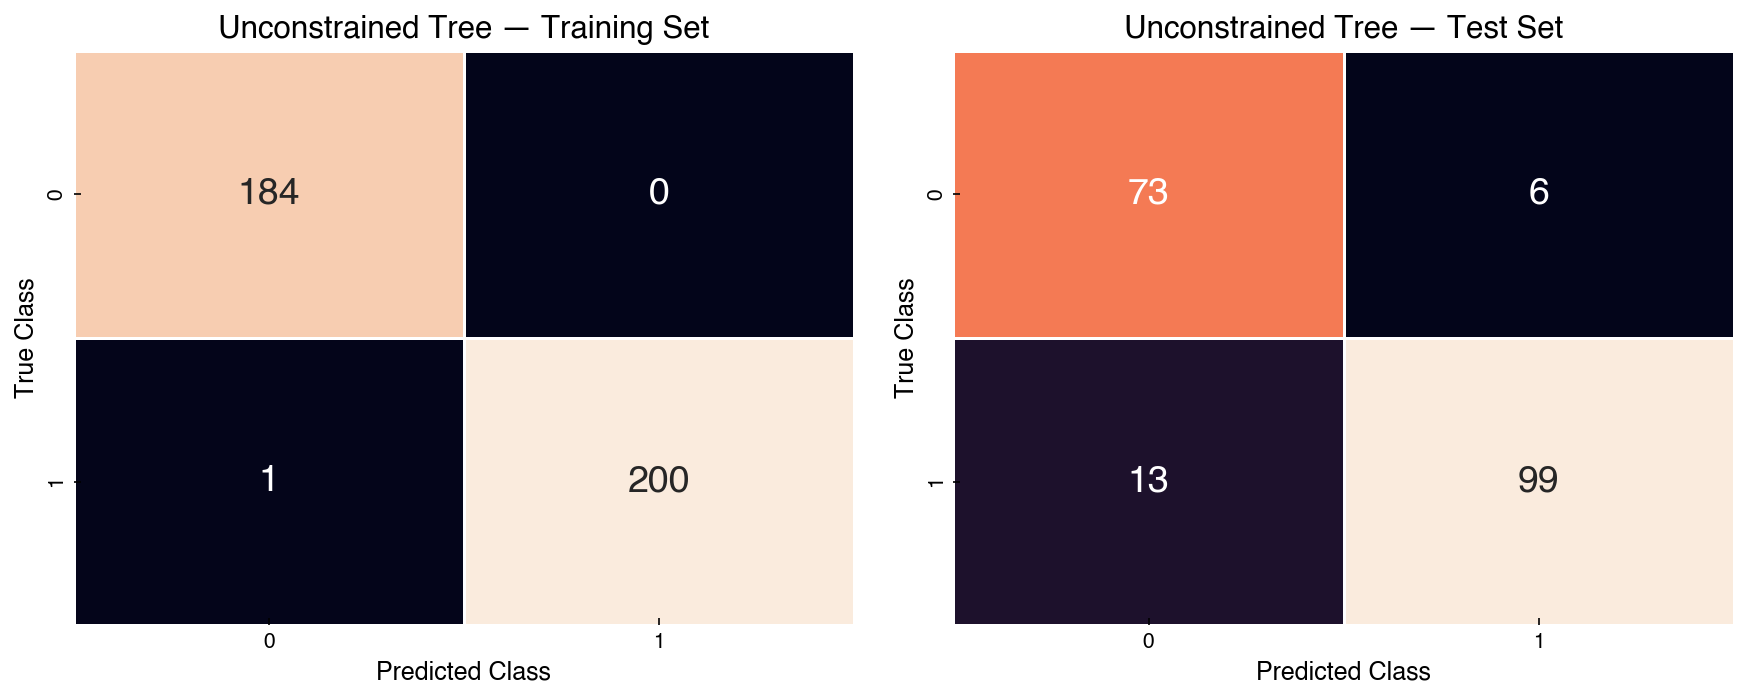

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

cm_train = confusion_matrix(y_train, dtree.predict(X_train))
cm_test  = confusion_matrix(y_test,  dtree.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_train, annot=True, cbar=False, linewidth=0.5, ax=axes[0], fmt='d')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')
axes[0].set_title('Unconstrained Tree — Training Set')

sns.heatmap(cm_test, annot=True, cbar=False, linewidth=0.5, ax=axes[1], fmt='d')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')
axes[1].set_title('Unconstrained Tree — Test Set')
plt.tight_layout()
plt.show()

The unconstrained tree memorizes the training data (perfect training accuracy) but
generalizes less well to the test set. This is the hallmark of high-variance
overfitting: the model has grown enough branches to perfectly partition every
training point, including those that are noise or outliers.
Limiting `max_depth` acts as regularization, forcing the tree to find broader
rules that capture the dominant structure rather than individual training samples:

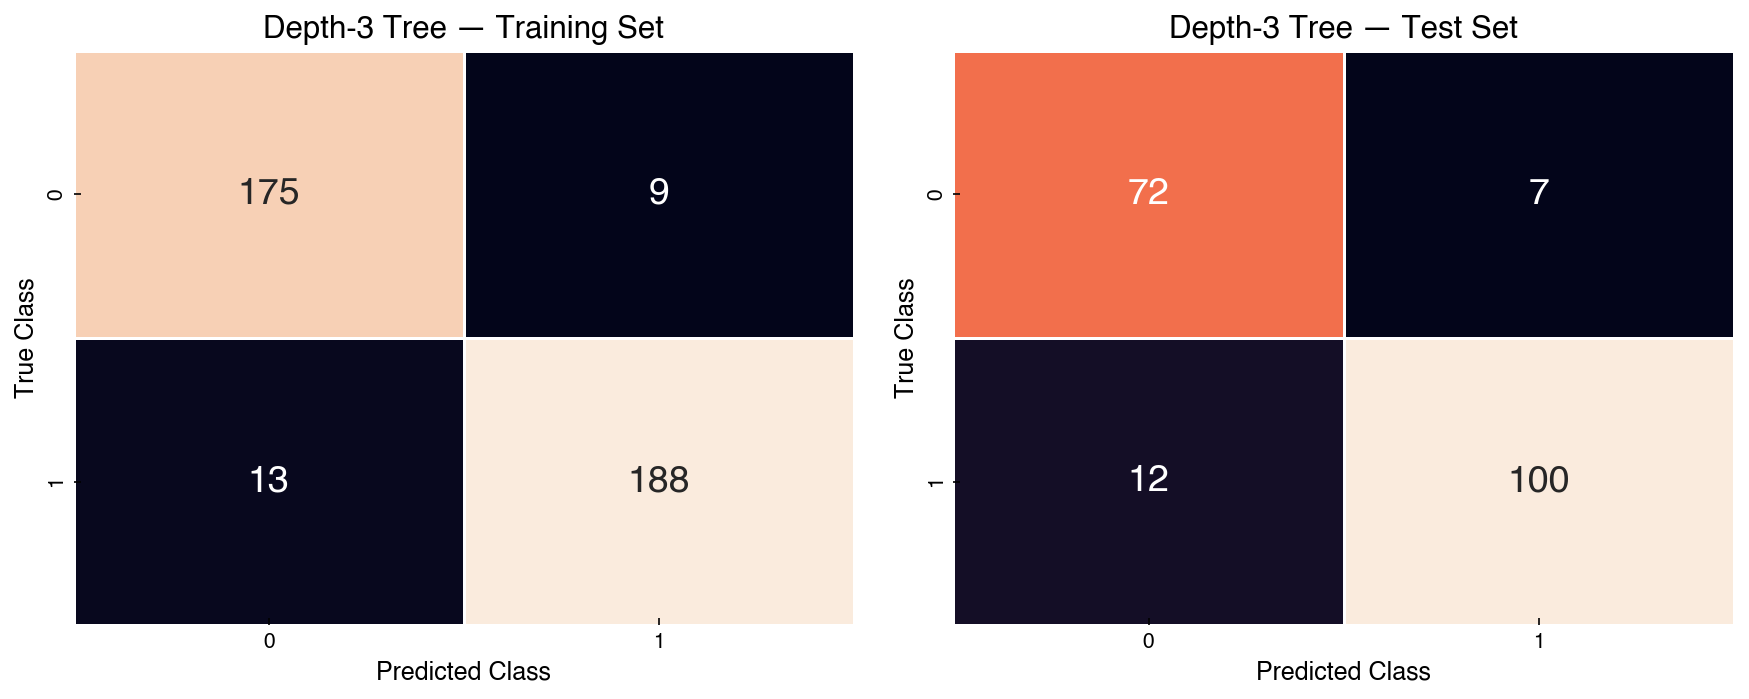

Depth-3 test accuracy: 0.901


In [21]:
dtree3 = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree3.fit(X_train, y_train)

cm_train3 = confusion_matrix(y_train, dtree3.predict(X_train))
cm_test3  = confusion_matrix(y_test,  dtree3.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_train3, annot=True, cbar=False, linewidth=0.5, ax=axes[0], fmt='d')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')
axes[0].set_title('Depth-3 Tree — Training Set')

sns.heatmap(cm_test3, annot=True, cbar=False, linewidth=0.5, ax=axes[1], fmt='d')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')
axes[1].set_title('Depth-3 Tree — Test Set')
plt.tight_layout()
plt.show()

print(f'Depth-3 test accuracy: {dtree3.score(X_test, y_test):.3f}')

The depth-3 tree has slightly lower training accuracy but comparable (or better) test
accuracy — a clear improvement in the bias-variance trade-off. This illustrates
a general principle: a simpler model that captures the dominant signal often
generalizes better than a complex model that fits every detail of the training data.

### Feature Importance

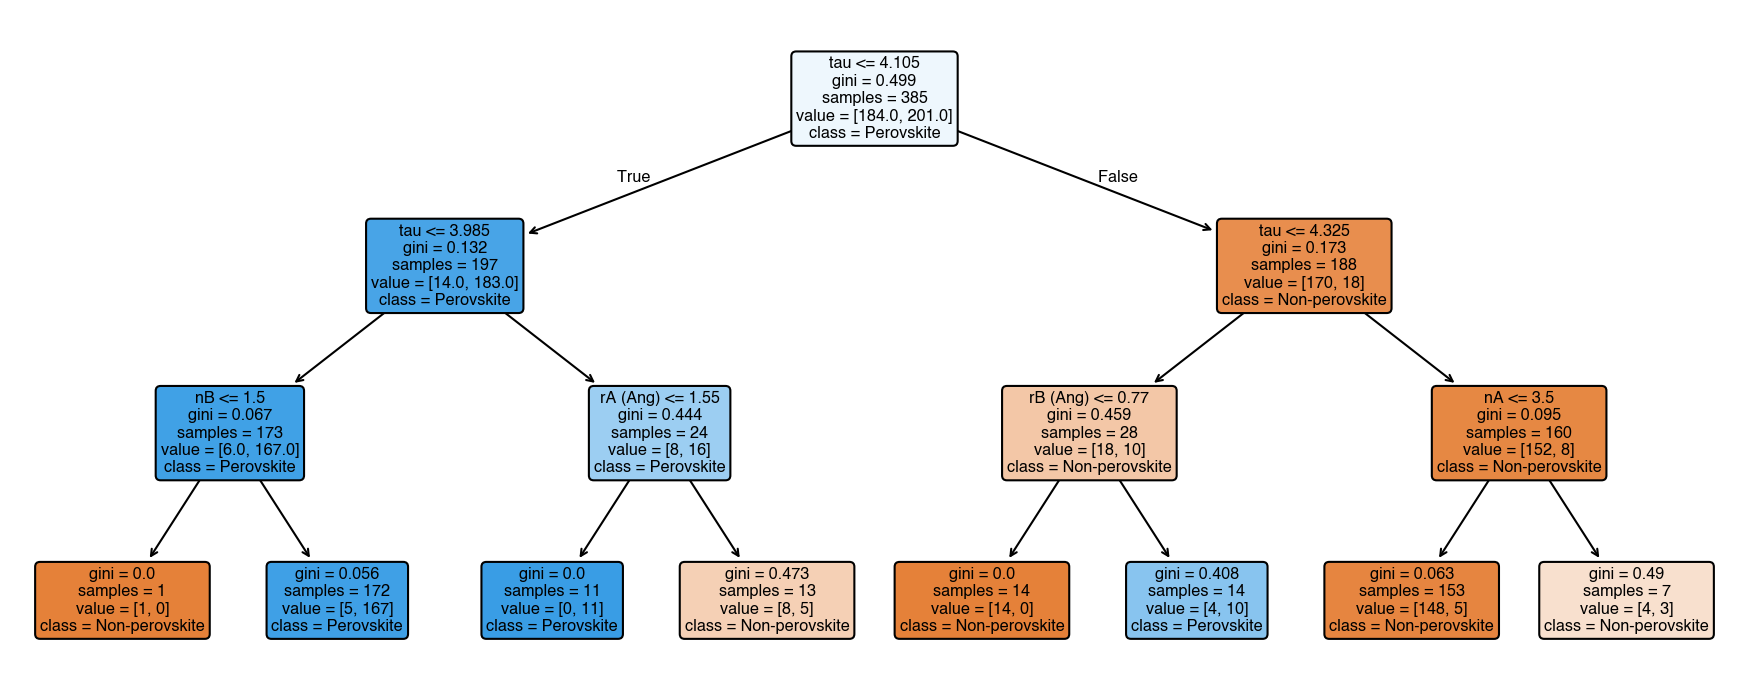

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(dtree3, filled=True, rounded=True, ax=ax,
          class_names=['Non-perovskite', 'Perovskite'],
          feature_names=feature_columns)
plt.tight_layout()
plt.show()

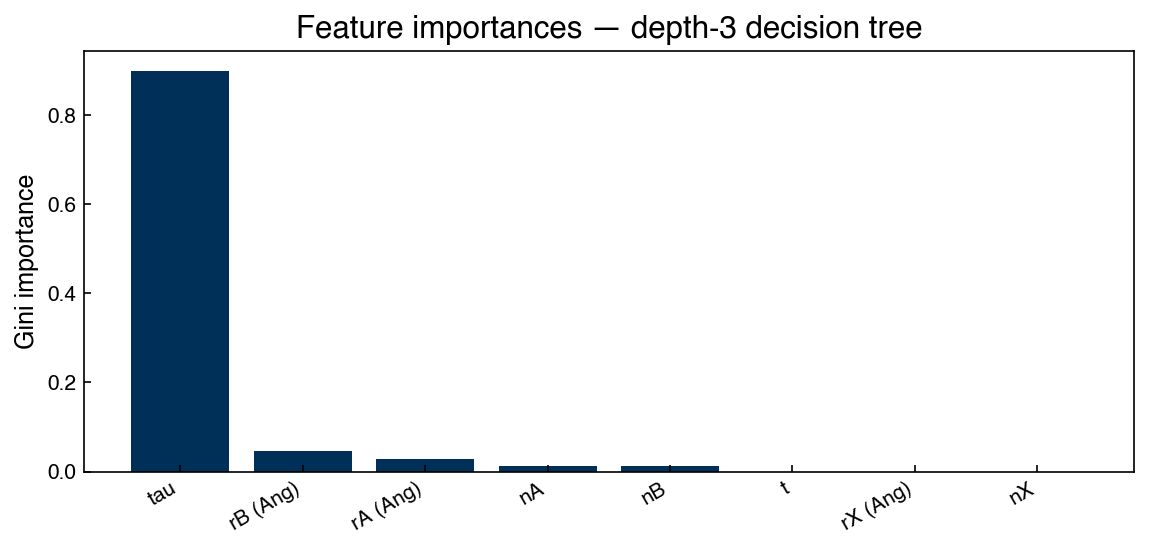

In [23]:
importances = dtree3.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(feature_columns)), importances[sorted_idx])
ax.set_xticks(range(len(feature_columns)))
ax.set_xticklabels([feature_columns[i] for i in sorted_idx], rotation=30, ha='right')
ax.set_ylabel('Gini importance')
ax.set_title('Feature importances — depth-3 decision tree')
plt.tight_layout()
plt.show()

:::{note}
The feature `tau` (index 7) consistently appears near the root of the decision tree
and carries the highest Gini importance. This aligns with the finding in Bartel et al.
(2019) that $\tau$ is a better predictor of perovskite stability than the traditional
Goldschmidt tolerance factor $t$. The ability to read feature importances directly
from a decision tree is one of its most practically valuable properties in materials
science and chemical engineering applications.
:::

:::{exercise}
:label: ex-cls-tree-rf

Import `RandomForestClassifier` from `sklearn.ensemble` and train it on the
perovskite training set with `n_estimators=100` and `random_state=42`.
Print the test accuracy and compare it to the depth-3 decision tree above.
Then plot the feature importances from the random forest alongside those from
the depth-3 tree and note any differences in the relative ranking of `tau` and `t`.
:::

---

## Linear Discriminant Analysis

In Topic 2.5 we saw that **Partial Least Squares** is a supervised dimensionality
reduction technique for regression — it finds latent directions that maximize covariance
between $X$ and $y$. The classification analogue is **Linear Discriminant Analysis
(LDA)**: it finds directions that maximize the separation between class centroids relative
to the within-class spread.

LDA is simultaneously a **dimensionality reduction** method (project $n$-dimensional
features to at most $C - 1$ dimensions, where $C$ is the number of classes) and a
**classifier** (assign points to the class whose centroid is nearest in the projected
space). The decision boundaries are hyperplanes perpendicular to the LDA axes.

### The LDA Algorithm: Manual Derivation

We will step through the five-step derivation on a two-class toy dataset. Applying
the scikit-learn implementation to a real 10-class, high-dimensional dataset is
deferred to [Dimensionality Reduction](../5-exploratory_data_analysis/Topic5.2-Dimensionality_Reduction)
in Module 5, where LDA reappears as the supervised counterpart of PCA.

#### Step 1 — Class Centroids

Class 0 centroid: [0.98137069 4.28756914]
Class 1 centroid: [2.02437058 0.95630346]


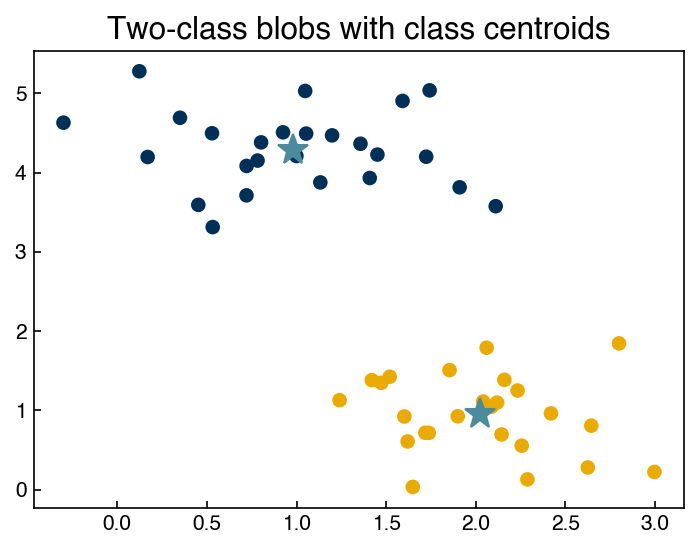

In [24]:
from sklearn.datasets import make_blobs

np.random.seed(0)
X_blobs, y_blobs = make_blobs(
    n_samples=50, centers=2, cluster_std=0.5, n_features=2, random_state=0)

classes = [0, 1]
mean_vectors = []
for cl in classes:
    mu_cl = X_blobs[y_blobs == cl].mean(axis=0)
    mean_vectors.append(mu_cl)
    print(f'Class {cl} centroid: {mu_cl}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=[clrs[yi] for yi in y_blobs])
for mv in mean_vectors:
    ax.plot(mv[0], mv[1], marker='*', markersize=15, c=clrs[2])
ax.set_title('Two-class blobs with class centroids')
plt.tight_layout()

#### Step 2 — Intra-class Covariance

The within-class (intra-class) covariance measures the spread of points around their
own class centroid. LDA assumes all classes share the same covariance matrix, so we
average:

In [25]:
class_covs = []
for cl, center in zip(classes, mean_vectors):
    subX = X_blobs[y_blobs == cl]
    subX_centered = subX - center
    cov = (subX_centered.T @ subX_centered) / (subX.shape[0] - 1)
    class_covs.append(cov)

# Pooled (averaged) intra-class covariance
intra = sum(class_covs) / len(class_covs)
print('Intra-class covariance:\n', intra)

Intra-class covariance:
 [[ 0.28134397 -0.04196723]
 [-0.04196723  0.24020378]]


#### Step 3 — Inter-class Covariance

The between-class (inter-class) covariance measures the spread of the class centroids
themselves:

In [26]:
center_array = np.array(mean_vectors)
inter = np.cov(center_array.T)
print('Inter-class covariance:\n', inter)

Inter-class covariance:
 [[ 0.54392438 -1.73725486]
 [-1.73725486  5.54866553]]


#### Step 4 — Composite Covariance Eigendecomposition

We want directions where between-class variance is large and within-class variance is
small. The composite matrix $C_\text{intra}^{-1} C_\text{inter}$ achieves this:

Eigenvalues: [ 0.         23.48758374]


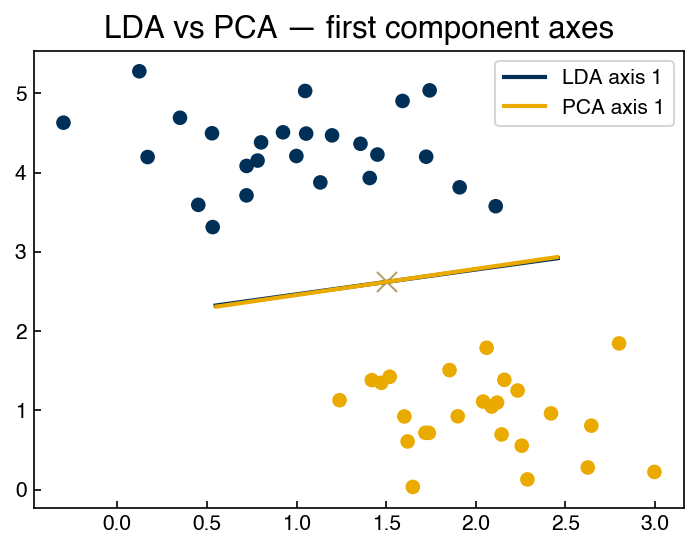

In [27]:
comp = np.linalg.inv(intra) @ inter
eig_vals, eig_vecs = np.linalg.eig(comp)
eig_vecs = eig_vecs.T   # rows are eigenvectors

print('Eigenvalues:', eig_vals)

LDvec1 = eig_vecs[0]
LDvec2 = eig_vecs[1]
mu_all = X_blobs.mean(axis=0)

# PCA axes for comparison
cov_all = np.cov(X_blobs.T)
_, pc_vecs = np.linalg.eig(cov_all)
pc_vecs = pc_vecs.T
PCvec1 = pc_vecs[0]

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=[clrs[yi] for yi in y_blobs])
ax.plot(*mu_all, marker='x', color=clrs[3], markersize=10)
ax.plot([mu_all[0] - LDvec1[0], mu_all[0] + LDvec1[0]],
        [mu_all[1] - LDvec1[1], mu_all[1] + LDvec1[1]],
        '-', color=clrs[0], label='LDA axis 1')
ax.plot([mu_all[0] - PCvec1[0], mu_all[0] + PCvec1[0]],
        [mu_all[1] - PCvec1[1], mu_all[1] + PCvec1[1]],
        '-', color=clrs[1], label='PCA axis 1')
ax.legend()
ax.set_title('LDA vs PCA — first component axes')
plt.tight_layout()

LDA's axis points from one class centroid toward the other; PCA's axis points toward
maximum total variance regardless of class labels. For well-separated clusters these
often agree, but they diverge when class variance is not aligned with inter-class
separation.

#### Step 5 — Decision Boundary

The LDA decision boundary is the hyperplane perpendicular to the discriminant axis,
passing through the mean of the two class centroids. In 2D, rotating the eigenvector
by 90° gives the boundary direction:

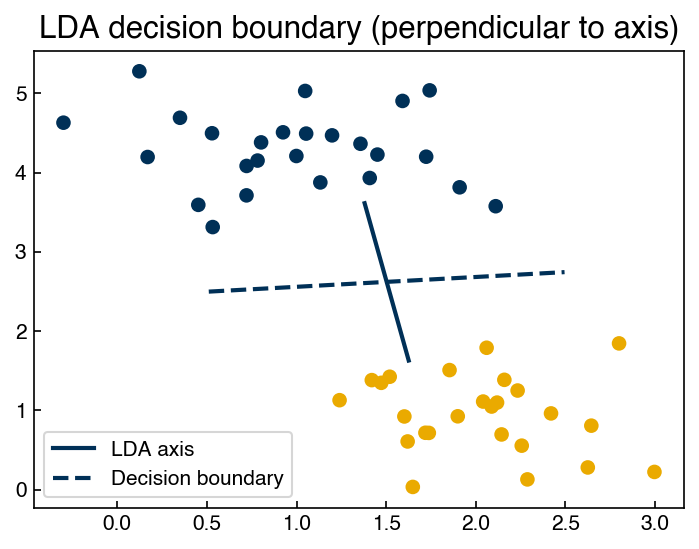

In [28]:
boundary = np.array([[0, -1], [1, 0]]) @ LDvec2

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=[clrs[yi] for yi in y_blobs])
ax.plot([mu_all[0] - LDvec2[0], mu_all[0] + LDvec2[0]],
        [mu_all[1] - LDvec2[1], mu_all[1] + LDvec2[1]],
        '-', color=clrs[0], label='LDA axis')
ax.plot([mu_all[0] - boundary[0], mu_all[0] + boundary[0]],
        [mu_all[1] - boundary[1], mu_all[1] + boundary[1]],
        '--', color=clrs[0], label='Decision boundary')
ax.legend()
ax.set_title('LDA decision boundary (perpendicular to axis)')
plt.tight_layout()

:::{note}
**LDA vs. PLS: the supervised dimensionality reduction pair**
LDA (for classification) and PLS (for regression) occupy symmetric roles: both find
linear combinations of features supervised by the output, and both are especially useful
when the number of features is large relative to the number of samples. The key
difference is the type of output variable — discrete class labels for LDA, continuous
values for PLS.
:::

:::{exercise}
:label: ex-cls-lda-perov

Apply the five-step manual LDA derivation to the perovskite dataset, using the eight
numeric features (`X_perov`) and labels (`y_perov`, classes $-1$/$+1$):

1. Compute the two class centroids and the pooled intra-class covariance matrix.
2. Compute the inter-class covariance and the eigendecomposition of the composite
   matrix $C_\text{intra}^{-1} C_\text{inter}$.
3. Project the data onto the leading LDA eigenvector (with two classes there is only
   one meaningful component) and plot overlapping histograms of the projected values
   for each class.
4. Repeat the projection using the leading eigenvector of the total covariance matrix
   (the first PCA component) and compare the class overlap in the two histograms.
   Which projection separates the classes better, and why?
:::

---

## Summary

- The perovskite dataset illustrates the full classification workflow on real data:
  exploratory scatter plots, train/test splitting, hyperparameter search on the
  training set, and evaluation on held-out data.

- **Kernel transformation** maps the original feature space into a higher-dimensional
  similarity space, enabling a linear classifier to find non-linear boundaries.
  The RBF kernel with a well-chosen $\gamma$ can dramatically improve accuracy over
  a raw linear SVM on the same features. The parameter $\gamma$ controls the width
  of each Gaussian: large $\gamma$ creates narrow kernels sensitive only to very
  nearby points (risk of overfitting); small $\gamma$ creates broad kernels that
  average over large neighborhoods (risk of underfitting).

- **`GridSearchCV`** automates the search over $C$ and $\gamma$ using cross-validation
  on the training set only — the test set is never touched until final evaluation.

- **Accuracy** is a misleading metric for imbalanced datasets; **precision** and
  **recall** (and the combined F1 score) give a more complete picture of classifier
  performance.

- **Categorical variables** (like element identity) must not be converted to raw
  integers; **one-hot encoding** replaces each category with a binary indicator
  column so that distance-based algorithms can compare categories correctly.
  `pd.get_dummies` is convenient for exploration; `sklearn.preprocessing.OneHotEncoder`
  inside a `Pipeline` is the leakage-safe production pattern.

- **Decision trees** on real data are highly prone to overfitting when unconstrained,
  but `max_depth` regularization recovers competitive generalization. Their
  interpretability — readable splitting rules and feature importance scores — makes
  them especially useful in science and engineering applications where understanding
  *why* a model makes a prediction matters as much as accuracy.

- **Linear Discriminant Analysis (LDA)** finds projections that maximize between-class
  variance relative to within-class variance — the supervised analogue of PCA for
  classification. It reduces $p$-dimensional features to at most $C-1$ dimensions
  ($C$ = number of classes) and serves as both a linear classifier and a preprocessing
  step for non-linear classifiers. LDA projections show better class separation than
  PCA projections because they use the class labels; PCA maximizes total variance
  regardless of class identity. LDA is applied to a real 10-class dataset in Module 5
  (Dimensionality Reduction).

## Additional Reading

- Bartel, C. J. et al. (2019), "New tolerance factor to predict the stability of
  perovskite oxides and halides," *Science Advances* 5(2), eaav0693 — the source
  paper for this dataset
- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*, Ch. 12
  (SVMs and kernels), Ch. 9 (Decision Trees) —
  [free PDF](https://hastie.su.domains/ElemStatLearn/)
- scikit-learn User Guide:
  [SVM](https://scikit-learn.org/stable/modules/svm.html),
  [GridSearchCV](https://scikit-learn.org/stable/modules/grid_search.html),
  [Decision Trees](https://scikit-learn.org/stable/modules/tree.html)